# Fig. 02: Pseudoproxies with the Truth SST fields

In [ ]:
import os
os.chdir('/glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/notebooks')
import numpy as np
import pandas as pd
import xarray as xr
import x4c
import datetime
print(f'Last update: {datetime.date.today()}')

Last update: 2026-06-12


## Load Pseudoproxy Data

In [2]:
class Case:
    pass

class Obs:
    def __init__(self, df):
        self.df = df

case = {}

case['P'] = Case()
case['P'].truth = xr.open_dataarray('../pseudoproxy/truth_Plio400ppm_ann_SST_regrid.nc')
case['P'].obs = Obs(pd.read_json('../pseudoproxy/ppe_Plio400ppm_obs_SST_R0.01.json'))

case['N'] = Case()
case['N'].truth = xr.open_dataarray('../pseudoproxy/truth_Plio490ppm_ann_SST_regrid.nc')
case['N'].obs = Obs(pd.read_json('../pseudoproxy/ppe_Plio490ppm_obs_SST_R4.00.json'))

## Visualization

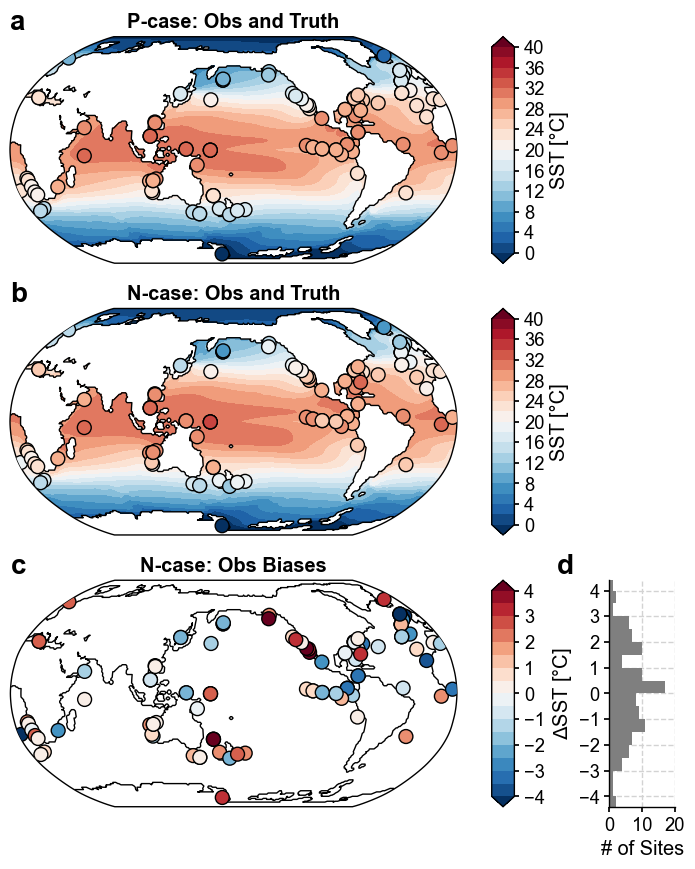

Figure saved at: "../figs/ppe_truth_obs.pdf"


In [3]:
x4c.set_style('journal', font_scale=1.2)

levels = np.linspace(0, 40, 21)
ticks = np.linspace(0, 40, 11)
label = 'SST [°C]'

fig, ax = x4c.visual.subplots(
    figsize=(10, 10),
    nrow=3, ncol=10,
    ax_loc={
        'P': (0, slice(0, 9)),
        'N': (1, slice(0, 9)),
        'B': (2, slice(0, 9)),
        'D': (2, slice(9, 10)),
    },
    projs={
        'P': 'Robinson',
        'N': 'Robinson',
        'B': 'Robinson',
    },
    projs_kws={
        'P': {'central_longitude': 180},
        'N': {'central_longitude': 180},
        'B': {'central_longitude': 180},
    },
    annotation=True, annotation_separate=True,
    annotation_kws={
        'P': {'loc_x': 0., 'style': ''},
        'N': {'loc_x': 0., 'style': ''},
        'B': {'loc_x': 0., 'style': ''},
        'D': {'loc_x': -0.8, 'style': ''},
    },
)

case['P'].truth.x.plot(
    ax=ax['P'],
    levels=levels,
    cbar_kwargs={'ticks': ticks, 'label': label},
    cyclic=True,
    title='P-case: Obs and Truth',
    df_sites=case['P'].obs.df[['lon', 'lat', 'value']],
    legend=False,
)
case['N'].truth.x.plot(
    ax=ax['N'],
    levels=levels,
    cbar_kwargs={'ticks': ticks, 'label': label},
    cyclic=True,
    title='N-case: Obs and Truth',
    df_sites=case['N'].obs.df[['lon', 'lat', 'value']],
    legend=False,
)

levels = np.linspace(-4, 4, 17)
ticks = np.linspace(-4, 4, 9)
label = r'$\Delta$SST [°C]'
case['N'].truth.where(case['N'].truth.isnull(), other=np.inf).x.plot(
    ax=ax['B'],
    levels=levels,
    cbar_kwargs={'ticks': ticks, 'label': label},
    cyclic=True,
    title='N-case: Obs Biases',
    df_sites=case['N'].obs.df[['lon', 'lat', 'noise']].rename(columns={'noise': 'value'}),
    legend=False,
)

ax['D'].hist(case['N'].obs.df['noise'], bins=np.linspace(-4.5, 4.5, 19), orientation='horizontal', color='tab:grey')
ax['D'].set_xlabel('# of Sites')
ax['D'].set_xticks([0, 10, 20])
ax['D'].set_yticks(ticks)
ax['D'].set_ylim([-4.4, 4.4])

x4c.showfig(fig)
x4c.savefig(fig, '../figs/ppe_truth_obs.pdf')